[![MIT licensed](https://img.shields.io/badge/license-MIT-blue.svg)](https://opensource.org/licenses/MIT)

# rocPyJpegDecode 
### Copyright © Advanced Micro Devices, Inc., or its affiliates.
#### SPDX-License-Identifier:  MIT License
### JPEG Decode Python Sample
#### Single file, data

In [1]:
import torch
import pyRocJpegDecode.decoder as jdec
from PIL import Image
from IPython.display import display
import cv2

In [2]:
def display_tensor(tensor):
    arr = tensor.cpu().numpy()
    small_arr = cv2.resize(arr, (arr.shape[1] // 8, arr.shape[0] // 8), interpolation=cv2.INTER_LINEAR)
    img_resized = Image.fromarray(small_arr)
    display(img_resized)

Using the rocPyJpeg **`read`** API to read and decode from a file path:

In [3]:
device_id = 0       # change to the appropriate device id
backend = 0         # 0 for GPU 1 for CPU, change to the appropriate one

# change it to the JPEG image full path on your system
# "/opt/rocm" the ROCm path might be different on your system
img_full_path = "/opt/rocm/share/rocjpeg/images/mug_420.jpg" 

decoder = jdec.decoder(device_id, backend)

cs = jdec.DecodeSource(img_full_path).code_stream()
width = cs.width
height = cs.height
image1 = decoder.read(img_full_path)

print(f"\n width: {width} height: {width}")

Using GPU device 0: Radeon RX 7900 XT[gfx1100] on PCI bus 03:00.0

 width: 3840 height: 3840


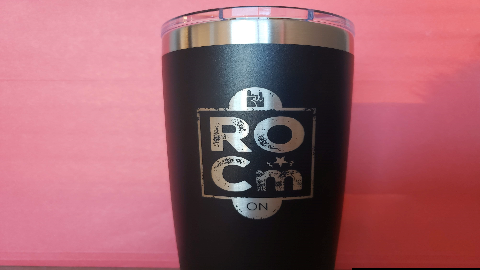

In [4]:
tensor1 = torch.from_numpy(image1.to_numpy())
display_tensor(tensor1)

Or the rocPyJpeg **`decode`** API to decode from an in-memory encoded stream: 

In [5]:
try:
    with open(img_full_path, 'rb') as in_file:
        data = in_file.read()
        if not data:
            raise ValueError("File is empty.")
except Exception as e:
    print(f"Failed to read file: {e}")

image2 = decoder.decode(data)

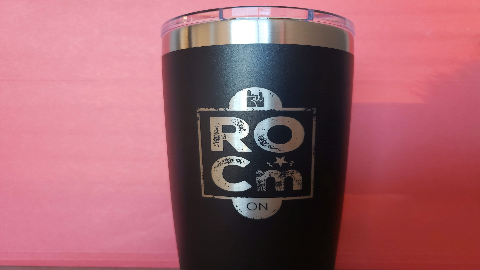

In [6]:
tensor2 = torch.from_numpy(image2.to_numpy())
display_tensor(tensor2)